<a href="https://colab.research.google.com/github/salihaliyi73/PyTorch-works/blob/main/Basic_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Build NN***

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F #help to move our data forward(Ex.Activation function)

**Crate a model class that inherits nn.module**\
In this we use mostly class-based Object-Oriented programming with python not functional programming

In [3]:
# create a Model class tha inherits nn.Module
class Model(nn.Module):
  #CREATE FUNCTION OF THAT CREATE AND INITIALIZES THE NN Layers
  # Number of input layer (4 feature of the flower)-->
  # Hidden layer1(number of neurons)-->H2(No N)...-->
  # Output (3 classes of  flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3 ):
   super().__init__()#instantiate our nn.Module
   self.fc1 = nn.Linear(in_features, h1) #fc=fully connected
   self.fc2 =nn.Linear(h1,h2)
   self.out =nn.Linear(h2,out_features)
# CREATE A FUNCTION THAT MOVE data FORWARD FROME ONE LAYER TO THE OTHER LAYER
  def forward(self,x):
    x=F.relu(self.fc1(x))#relu=rectified linear unit(Activation function)
    x=F.relu(self.fc2(x))
    x=self.out(x)
    return x







## **CREATE MANUAL SEED** *italicized text*

In [4]:
# Pick a manual number for randomization
torch.manual_seed(41)# set random seed(ex. 41) for reproducible weight initialization.

**Create an instance of model**

In [5]:
model=Model() # Model the class(blue print), where model is the instance object (the actual NN you will train and use)

# **LOAD DATA, TRAIN AND TEST OUR NN**

In [6]:
# pandas is python libarary used for loading, organizing, manipulating and analyzing data
import pandas as pd
# matplotlib is python libarary used for creating graphs, charts and plots
#pyplot is a module inside matplotlib that provides plotting functions
# plt creates shorter alias, instead of of typing matplotlib.pyplot(u can use another short like p)
import matplotlib.pyplot as plt
#Display Matplotlib plots inside the jupyter Notebook
%matplotlib inline

**Load data(there are different ways to load data)**

In [7]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
# Read the CSV file from the specified url and store it in my_df dataframe
my_df = pd.read_csv(url)

In [8]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [9]:
#Display the first 5 rows of the dataframe
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [10]:
#Display the last 5 rows of the dataframe
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [11]:
"""As machine learning work better with numbers
let change the elements of species to numbers"""
# Therefore change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

/tmp/ipykernel_1054/938982691.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


** input output data split! set x, y**

In [12]:
 # drop the last as its output/
 #so x goes with 4 column of features or input
 # axis=0--> Rows  axis=1-->Columns
x=my_df.drop('species', axis=1)
y=my_df['species'] # y for output


In [13]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
y

,species
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


**Convert them to numpy arrays**

In [15]:
x=x.values
y=y.values
print(type(x))

<class 'numpy.ndarray'>


In [16]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [17]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

# **Train_test data split**

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

**convert numpy array to tensors**

In [20]:
""" Convert input features from Numpy arrays to
PyTorch FloatTensors, because PyTorch NN operate on
tensors and feature values are decimal numbers."""
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

In [21]:
""" Convert class labels from Numpy arrays to
PyTorch LongTensors(long tensors store 64bit integers),
because PyTorch classification
operate on tensors and target labels are
integer class indices."""
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

**Loss**

In [22]:
"""set the criterion of the model to measure the error,
how far off the predictions are from the actual data"""
criterion = nn.CrossEntropyLoss()
"""choose optimizer,
set lr=learning rate(if error doesn't go down
after a bunch of iterations(epochs),
we lower our learnig rate(LARGE lr make big improvement quickly
 but overshoot may happen, so better to start with large lr and
 if not learning well(either loss constant and not reducing)
 try with lower lr ),
 model.parameters:pass all trainable weights and
 biases of the model to the optimizer for updating
 training, parameters are weight and biases
 nn.Linear(h1,h2) in the creation of model automaticlly creates
 two learnable parameters: weight matrix and bias vector
 Y=WiXi+b, weight tells the NN how important and input is
 (the input with high weight mean the the larger influence on the output)
 The bias shift the output up or down, making the model more flexible)"""
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


In [23]:
type(model.parameters)

method

In [24]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.2636, -0.2734,  0.3005, -0.3308],
         [-0.2350,  0.2720, -0.3718,  0.2452],
         [ 0.3045,  0.1357,  0.0896,  0.1933],
         [ 0.3782,  0.0407, -0.3600,  0.4613],
         [ 0.3666, -0.0116, -0.2923, -0.1937],
         [-0.4415,  0.3314, -0.0434,  0.3445],
         [ 0.1883, -0.0992, -0.3197,  0.1740],
         [-0.3208, -0.1111,  0.2972, -0.2723]], requires_grad=True),
 Parameter containing:
 tensor([-0.0245, -0.0679,  0.0573,  0.4814,  0.2923, -0.1877,  0.4425, -0.1626],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.1456,  0.1463, -0.0107, -0.3290,  0.3324, -0.0817,  0.2408, -0.2121],
         [-0.0361,  0.3031, -0.3068,  0.0136, -0.0046, -0.3022, -0.0685, -0.3241],
         [ 0.0764,  0.0595,  0.2023,  0.0088, -0.1424, -0.1275, -0.1320,  0.2750],
         [ 0.1133, -0.3520,  0.0632, -0.0472,  0.2579, -0.1034,  0.3086,  0.1093],
         [-0.3185,  0.0744, -0.0807,  0.1770, -0.3035, -0.0259,  0.2337,  0.1253],
       

In [25]:
for name, param in model.named_parameters():
    print(name, param.shape)

fc1.weight torch.Size([8, 4])
fc1.bias torch.Size([8])
fc2.weight torch.Size([9, 8])
fc2.bias torch.Size([9])
out.weight torch.Size([3, 9])
out.bias torch.Size([3])


# **TRAIN OUR MODEL**

In [26]:
# epochs? (one run thruogh all the training data in our network
epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(x_train) #Get predicted results

  # Measure the loss/error, gonna be high at first
  loss=criterion(y_pred, y_train) #compare predicted values vs the actual (y_train)

  #keep track of our losses
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i%10 == 0:
    print (f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation
  # and feed it back through the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch: 0 and loss: 1.1251550912857056
Epoch: 10 and loss: 1.0096259117126465
Epoch: 20 and loss: 0.8157405853271484
Epoch: 30 and loss: 0.585706353187561
Epoch: 40 and loss: 0.3999636471271515
Epoch: 50 and loss: 0.2676880657672882
Epoch: 60 and loss: 0.17942363023757935
Epoch: 70 and loss: 0.12151690572500229
Epoch: 80 and loss: 0.0860118418931961
Epoch: 90 and loss: 0.06520850956439972


**Plot**

Text(0, 0.5, 'loss/error')

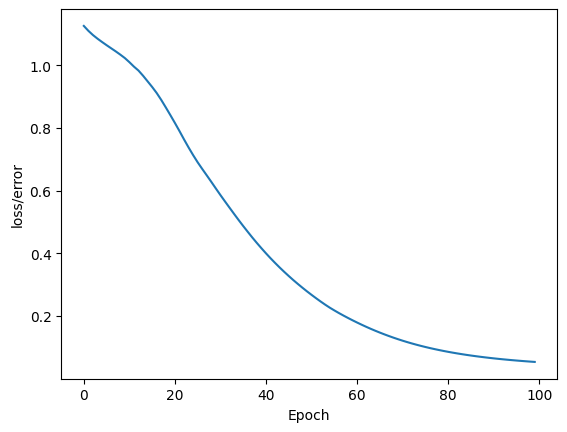

In [27]:
plt.plot(range(epochs), losses)
plt.xlabel('Epoch')
plt.ylabel("loss/error")


**EVALUATE OUR MODEL(TEST)**

In [28]:
# Evaluate model on test data set (validate model on test set)
with torch.no_grad(): #Basically turn off back propagation(during test back propagation not needed)
  y_eval = model.forward(x_test)
  loss = criterion(y_eval, y_test) #find the loss or error


In [29]:
loss

tensor(0.1315)

**More on test data comparison**

In [30]:
correct= 0
with torch.no_grad():
  for i, data in enumerate(x_test):
    y_val = model.forward(data)

    """ if you want to convert the result from intiger to name
    use the below code and instead of print y_test[i]
    print x

    if y_test[i]==0:
      x="setosa"
    elif y_test[i]==1:
      x="versicolor"
    else:
      x="virginica"
    """
    #will tell us what type of flower class our NN thinks it is
    print (f'{i+1}.) {str(y_val)} \t {y_val.argmax().item()} \t {y_test[i]} \t ')
    # the highest no in output is what NN class thinks
    # Ex. the first is 6.5.. is highest wich is class(2 or virginica)

# To check how many pridiction is correct or not
    if y_val.argmax().item() == y_test[i]:
      correct +=1
print(f'we got {correct} correct')


1.) tensor([-5.8760,  4.4628,  6.5124]) 	 2 	 2 	 
2.) tensor([-7.5436,  4.1670,  9.7255]) 	 2 	 2 	 
3.) tensor([-8.4504,  5.1271, 10.1987]) 	 2 	 2 	 
4.) tensor([-4.3398,  5.6267,  2.5608]) 	 1 	 1 	 
5.) tensor([-7.1825,  4.8754,  8.2992]) 	 2 	 2 	 
6.) tensor([-3.3974,  5.3463,  1.2803]) 	 1 	 1 	 
7.) tensor([-5.9231,  4.9822,  5.9997]) 	 2 	 2 	 
8.) tensor([-4.2881,  5.7003,  2.3889]) 	 1 	 1 	 
9.) tensor([-6.5356,  4.9257,  7.1260]) 	 2 	 2 	 
10.) tensor([-8.0509,  4.4129, 10.3286]) 	 2 	 2 	 
11.) tensor([-5.6762,  4.9500,  5.6215]) 	 2 	 2 	 
12.) tensor([ 4.5662, -2.2476, -2.8911]) 	 0 	 0 	 
13.) tensor([ 4.2571, -1.9967, -2.7330]) 	 0 	 0 	 
14.) tensor([-2.1108,  4.0515,  0.5799]) 	 1 	 1 	 
15.) tensor([ 3.4575, -1.2098, -2.3514]) 	 0 	 0 	 
16.) tensor([-5.4724,  5.1165,  5.0934]) 	 1 	 2 	 
17.) tensor([ 4.0557, -1.7949, -2.6492]) 	 0 	 0 	 
18.) tensor([-5.8075,  4.6053,  6.2458]) 	 2 	 1 	 
19.) tensor([ 4.4343, -2.1392, -2.8242]) 	 0 	 0 	 
20.) tensor([ 3.4527,

**EVALUATE NEW DATA ON THE NN**

****

In [32]:
# LET GIVE THE FOUR FEATURES AND THE MODELS GIVE YOU THE CLASS
new_iris=torch.tensor([4.7, 3.2, 1.1, 0.2])

In [33]:
with torch.no_grad():
  print(model(new_iris))


tensor([ 4.7599, -2.4338, -2.9756])


In [34]:
#may be another features
new_features=torch.tensor([2.5,1.6,0.8,4.2])

In [37]:
with torch.no_grad(): #no back propagation needed
  print(model(new_features))

tensor([-5.6832,  2.8138,  7.8531])
